In [1]:
import sys
from pathlib import Path

import yaml

sys.path.insert(0, str(Path().absolute().parent.parent.parent))

In [2]:
from matplotlib import pyplot as plt
import matplotlib.pyplot as plt
import seaborn as sns
# sns.set_theme(rc={'text.usetex' : True})
import numpy as np
import pandas as pd
from test.lib.files_utils import SimulationOutput, LisLoader, ISOTOPES, func

In [3]:
lis_loader = LisLoader(Path().absolute().parent / 'data' / 'LIS_Default2020_Proton')

In [10]:
output_files = Path().absolute().parent / 'data' / 'uncertainty' / 'outputs'
rows = []
for of in sorted(output_files.rglob('*.yaml')):
    date, _, part = of.parent.name.split('_')
    print(date, part)
    fluxes = SimulationOutput.from_yaml(yaml.load(of.read_text(), Loader=yaml.CLoader)).modulate(lis_loader)
    for i, flux in enumerate(fluxes):
        # print(flux.rig_flux.rigidity)
        # print(flux.rig_flux.to_energy(ISOTOPES.get('proton')).energy)
        # for r, f in zip(*flux.rig_flux):
        for r, f in zip(*flux.rig_flux.to_energy(ISOTOPES.get('proton'))):
            rows.append([date, part, i, r, f])

20111116 1024
20111116 16384
20111116 2048
20111116 4096
20111116 512
20111116 8192
20140917 1024
20140917 16384
20140917 2048
20140917 4096
20140917 512
20140917 8192
20150907 1024
20150907 16384
20150907 2048
20150907 4096
20150907 512
20150907 8192
20160827 1024
20160827 16384
20160827 2048
20160827 4096
20160827 512
20160827 8192
20170623 1024
20170623 16384
20170623 2048
20170623 4096
20170623 512
20170623 8192
20180929 1024
20180929 16384
20180929 2048
20180929 4096
20180929 512
20180929 8192


In [11]:
df = pd.DataFrame(rows, columns=['date', 'part', 'param', 'rig', 'flux'])
df['part'] = df['part'].astype(int)
df['param'] = df['param'].astype(int)
df['rig'] = df['rig'].astype(float)
df['flux'] = df['flux'].astype(float)
df.sort_values(df.columns.to_list(), inplace=True)
df.to_csv('uncertainty.csv', index=False)
df

,date,part,param,rig,flux
2520,20111116,512,0,0.010000,61.168213
2521,20111116,512,0,0.015800,88.609997
2522,20111116,512,0,0.025100,130.816759
2523,20111116,512,0,0.039800,223.760707
2524,20111116,512,0,0.063100,338.619566
...,...,...,...,...,...
20155,20180929,16384,29,15.800046,6.700193
20156,20180929,16384,29,25.100038,1.973098
20157,20180929,16384,29,39.800034,0.563706
20158,20180929,16384,29,63.100002,0.158039


[None, None]

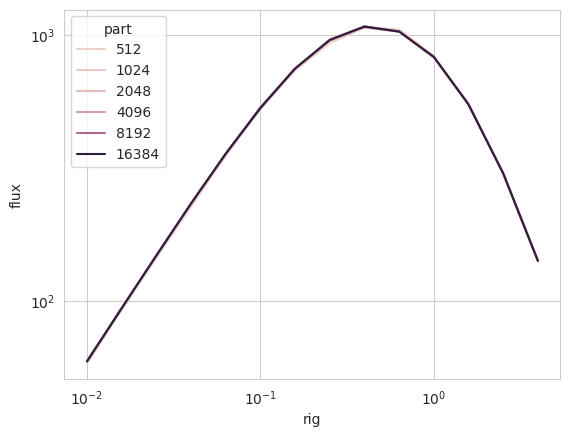

In [12]:
ax = sns.lineplot(
    df[(df['date'] == '20111116') & (df['rig'] < 5)],
    x='rig',
    y='flux',
    hue='part',
    errorbar=('ci', 1),

)
ax.set(xscale='log', yscale='log')

In [13]:
df2 = df.copy()
df2 = df2.groupby(['date', 'part', 'rig']).agg(flux_mean=('flux', 'mean'),
                                               flux_std=('flux', 'std')).reset_index()
df2['pois'] = (df2['part'].astype(float)) ** (-1 / 2)
df2['ratio'] = (df2['flux_std'] / df2['flux_mean']) / df2['pois']
df2

,date,part,rig,flux_mean,flux_std,pois,ratio
0,20111116,512,0.010000,58.801322,4.956274,0.044194,1.907231
1,20111116,512,0.015800,93.903600,5.023111,0.044194,1.210390
2,20111116,512,0.025100,145.430461,8.609483,0.044194,1.339543
3,20111116,512,0.039800,226.590427,12.901387,0.044194,1.288338
4,20111116,512,0.063100,354.444426,17.580700,0.044194,1.122336
...,...,...,...,...,...,...,...
751,20180929,16384,15.800046,6.703218,0.005362,0.007812,0.102382
752,20180929,16384,25.100038,1.974029,0.000836,0.007812,0.054230
753,20180929,16384,39.800034,0.563644,0.000229,0.007812,0.051937
754,20180929,16384,63.100002,0.158006,0.000036,0.007812,0.028836


[None,
 None,
 Text(0.5, 0, 'Energy'),
 Text(0, 0.5, '(sigma sim) / (sigma pois)')]

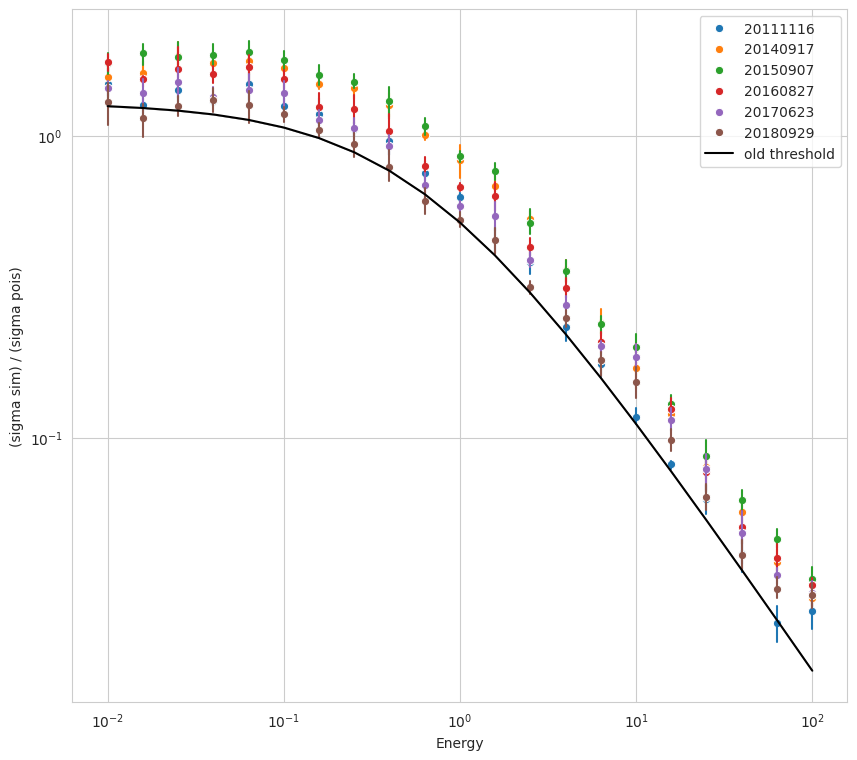

In [16]:
def threshold(t):
    return (1.29 * t**(-0.85)) / (t**-0.85 + 1.5)


fig, ax = plt.subplots(figsize=(10, 9))
axx = sns.lineplot(
    df2.query('(rig<1001)'),
    x='rig',
    y='ratio',
    hue='date',
    # errorbar=('ci', .05),
    err_style='bars', marker='o', linestyle='',
    ax=ax
)
sns.lineplot(
    x=df2.query('(rig<101)')['rig'],
    y=threshold(df2.query('(rig<101)')['rig']),
    color='k',
    label='old threshold',
    ax=ax,
)
axx.set(xscale='log', yscale='log', xlabel='Energy', ylabel=r'(sigma sim) / (sigma pois)')